Libraries Imported Successfully
Input Shape: torch.Size([100, 8])

Batch Normalization
Mean before normalization: tensor([10.0304, 10.0146,  9.8039, 10.7006, 10.0126, 10.3027,  9.3130, 10.8931])
Mean after normalization: tensor([-1.6332e-07, -2.7657e-07, -5.6028e-08,  7.6294e-08,  6.4373e-08,
        -8.1062e-08, -2.8610e-08, -1.7881e-07])
Variance after normalization: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

Layer Normalization
First sample mean: tensor(-1.1921e-07)
First sample variance: tensor(1.0000)

Backward Pass
Input Gradient Shape: torch.Size([100, 8])
Gamma Gradient Shape: torch.Size([1, 8])
Beta Gradient Shape: torch.Size([1, 8])

Normalization Comparison
Batch Normalization Mean: -0.0
Layer Normalization Mean: 0.0
Batch Normalization Variance: 1.0
Layer Normalization Variance: 1.0


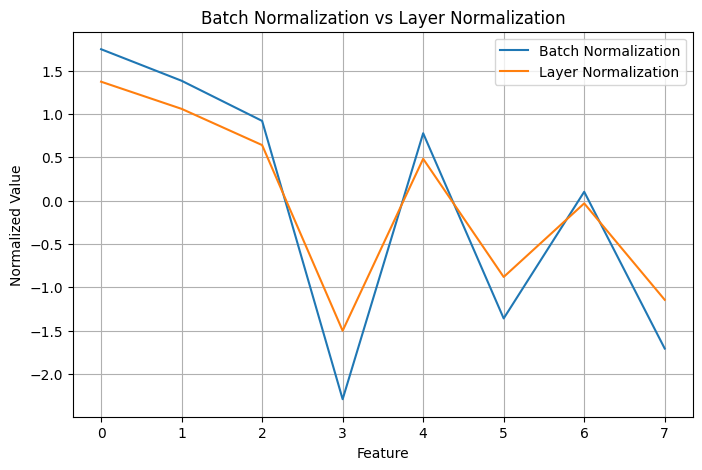


Normalization Experiment Completed


In [1]:
# ==========================================================
# TASK 5
# Custom Batch Normalization and Layer Normalization
# ==========================================================

# ----------------------------------------------------------
# Step 1 - Import Libraries
# ----------------------------------------------------------

import torch
import numpy as np
import matplotlib.pyplot as plt

print("Libraries Imported Successfully")


# ----------------------------------------------------------
# Step 2 - Create Sample Data
# ----------------------------------------------------------

torch.manual_seed(42)

X = torch.randn(100, 8) * 5 + 10

print("Input Shape:", X.shape)


# ----------------------------------------------------------
# Step 3 - Custom Batch Normalization
# ----------------------------------------------------------

def batch_normalization(X, gamma, beta, epsilon=1e-5):

    # Calculate mean
    mean = X.mean(dim=0, keepdim=True)

    # Calculate variance
    variance = X.var(
        dim=0,
        keepdim=True,
        unbiased=False
    )

    # Normalize
    X_normalized = (
        X - mean
    ) / torch.sqrt(variance + epsilon)

    # Scale and shift
    output = gamma * X_normalized + beta

    return output, X_normalized, mean, variance


# ----------------------------------------------------------
# Step 4 - Custom Layer Normalization
# ----------------------------------------------------------

def layer_normalization(X, gamma, beta, epsilon=1e-5):

    # Calculate mean for each sample
    mean = X.mean(
        dim=1,
        keepdim=True
    )

    # Calculate variance for each sample
    variance = X.var(
        dim=1,
        keepdim=True,
        unbiased=False
    )

    # Normalize
    X_normalized = (
        X - mean
    ) / torch.sqrt(variance + epsilon)

    # Scale and shift
    output = gamma * X_normalized + beta

    return output, X_normalized, mean, variance


# ----------------------------------------------------------
# Step 5 - Initialize Parameters
# ----------------------------------------------------------

features = X.shape[1]

gamma = torch.ones(1, features)

beta = torch.zeros(1, features)


# ----------------------------------------------------------
# Step 6 - Apply Batch Normalization
# ----------------------------------------------------------

batch_output, batch_norm, batch_mean, batch_variance = (
    batch_normalization(
        X,
        gamma,
        beta
    )
)


print("\nBatch Normalization")

print(
    "Mean before normalization:",
    torch.mean(X, dim=0)
)

print(
    "Mean after normalization:",
    torch.mean(batch_norm, dim=0)
)

print(
    "Variance after normalization:",
    torch.var(
        batch_norm,
        dim=0,
        unbiased=False
    )
)


# ----------------------------------------------------------
# Step 7 - Apply Layer Normalization
# ----------------------------------------------------------

layer_output, layer_norm, layer_mean, layer_variance = (
    layer_normalization(
        X,
        gamma,
        beta
    )
)


print("\nLayer Normalization")

print(
    "First sample mean:",
    torch.mean(layer_norm[0])
)

print(
    "First sample variance:",
    torch.var(
        layer_norm[0],
        unbiased=False
    )
)


# ----------------------------------------------------------
# Step 8 - Manual Backward Pass
# ----------------------------------------------------------

def normalization_backward(
    X,
    normalized,
    gamma,
    gradient
):

    # Number of features
    n = X.shape[1]

    # Gradient of gamma
    dgamma = torch.sum(
        gradient * normalized,
        dim=0,
        keepdim=True
    )

    # Gradient of beta
    dbeta = torch.sum(
        gradient,
        dim=0,
        keepdim=True
    )

    # Gradient with respect to input
    dx = (
        gamma / n
    ) * (
        n * gradient
        - torch.sum(
            gradient,
            dim=1,
            keepdim=True
        )
        - normalized * torch.sum(
            gradient * normalized,
            dim=1,
            keepdim=True
        )
    )

    return dx, dgamma, dbeta


# ----------------------------------------------------------
# Step 9 - Test Backward Pass
# ----------------------------------------------------------

gradient = torch.ones_like(X)

dx, dgamma, dbeta = normalization_backward(
    X,
    layer_norm,
    gamma,
    gradient
)


print("\nBackward Pass")

print(
    "Input Gradient Shape:",
    dx.shape
)

print(
    "Gamma Gradient Shape:",
    dgamma.shape
)

print(
    "Beta Gradient Shape:",
    dbeta.shape
)


# ----------------------------------------------------------
# Step 10 - Compare Batch and Layer Normalization
# ----------------------------------------------------------

batch_mean_value = torch.mean(
    batch_norm
).item()

layer_mean_value = torch.mean(
    layer_norm
).item()

batch_variance_value = torch.var(
    batch_norm,
    unbiased=False
).item()

layer_variance_value = torch.var(
    layer_norm,
    unbiased=False
).item()


print("\nNormalization Comparison")

print(
    "Batch Normalization Mean:",
    round(batch_mean_value, 4)
)

print(
    "Layer Normalization Mean:",
    round(layer_mean_value, 4)
)

print(
    "Batch Normalization Variance:",
    round(batch_variance_value, 4)
)

print(
    "Layer Normalization Variance:",
    round(layer_variance_value, 4)
)


# ----------------------------------------------------------
# Step 11 - Plot Normalized Values
# ----------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    batch_norm[0].numpy(),
    label="Batch Normalization"
)

plt.plot(
    layer_norm[0].numpy(),
    label="Layer Normalization"
)

plt.xlabel("Feature")

plt.ylabel("Normalized Value")

plt.title("Batch Normalization vs Layer Normalization")

plt.legend()

plt.grid()

plt.show()


# ----------------------------------------------------------
# Step 12 - Experiment Completed
# ----------------------------------------------------------

print("\nNormalization Experiment Completed")